# SVM Method Demonstration In Python
#### Credit Scoring Problem (Using Bank Loan KNN Data)

## **Objective:** Build and evaluate a *Support Vector Machine (SVM)* classification model to predict whether a loan applicant is likely to **default** using a real bank loan dataset.


## 1. Background
Credit scoring is a fundamental problem in **retail banking** and **consumer finance**. Banks need to assess the **creditworthiness** of applicants before approving loans, credit cards, or overdraft limits.

Typical business questions include:
- What is the probability that an applicant will **default** on a loan?
- Which characteristics (employment, existing debt, address stability, etc.) are associated with higher risk?

It follows the same structure as our KNN notebook:

1. Importing and exploring the data
2. Data cleaning and preparation
3. Train–test split
4. Building an SVM classifier
5. Getting predicted probabilities
6. Choosing a custom cutoff
7. Confusion matrix and performance metrics
8. ROC curve and AUC

## 2. Data Description
We work with a bank loan dataset where each row corresponds to one **loan applicant**.

| Variable   | Type      | Description                                                   |
|------------|-----------|---------------------------------------------------------------|
| `SN`       | Integer   | Serial number / ID of the applicant (identification only)    |
| `AGE`      | Numeric   | Age band of the applicant (coded categories 1–6)             |
| `EMPLOY`   | Numeric   | Years of employment (or employment band)                      |
| `ADDRESS`  | Numeric   | Years at current address / stability of residence             |
| `DEBTINC`  | Numeric   | Debt-to-income ratio (%)                                      |
| `CREDDEBT` | Numeric   | Credit card debt                                              |
| `OTHDEBT`  | Numeric   | Other debts                                                   |
| `DEFAULTER`| Binary    | Target variable: 1 = default, 0 = non-default                |


## 1. Importing the Libraries

In [48]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    classification_report
)

# Display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## 2. Importing Data

We will use a **bank loan dataset** where the target variable is whether the customer is a **loan defaulter**.

In [49]:
# Read the data
data = pd.read_csv("BANK LOAN.csv")

# Take a quick look at the data
data.head()

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
0,1,3,17,12,9.3,11.36,5.01,1
1,2,1,10,6,17.3,1.36,4.00,0
2,3,2,15,14,5.5,0.86,2.17,0
3,4,3,15,14,2.9,2.66,0.82,0
4,5,1,2,0,17.3,1.79,3.06,1


### 2.1 Data Snapshot and Structure

In [50]:
# Shape of the dataset
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

# Data types and missing values
data.info()

Number of rows: 700
Number of columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SN         700 non-null    int64  
 1   AGE        700 non-null    int64  
 2   EMPLOY     700 non-null    int64  
 3   ADDRESS    700 non-null    int64  
 4   DEBTINC    700 non-null    float64
 5   CREDDEBT   700 non-null    float64
 6   OTHDEBT    700 non-null    float64
 7   DEFAULTER  700 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 43.9 KB


We use `info()` to:
- Confirm that categorical variables have been correctly converted (if already done)
- Check the data types of all variables
- See if there are any missing values before moving to SVM modelling.

### 2.2 Basic Exploratory Data Analysis (EDA)

In [51]:
# Summary statistics for numeric variables
data.describe()

,SN,AGE,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,1.902857,8.388571,8.278571,10.260571,1.553457,3.058229,0.261429
std,202.21688,0.765301,6.658039,6.824877,6.827234,2.117209,3.287524,0.439727
min,1.00000,1.000000,0.000000,0.000000,0.400000,0.010000,0.050000,0.000000
25%,175.75000,1.000000,3.000000,3.000000,5.000000,0.370000,1.047500,0.000000
50%,350.50000,2.000000,7.000000,7.000000,8.600000,0.855000,1.985000,0.000000
75%,525.25000,2.000000,12.000000,12.000000,14.125000,1.905000,3.927500,1.000000
max,700.00000,3.000000,31.000000,34.000000,41.300000,20.560000,27.030000,1.000000


In [52]:
# Check the distribution of the target variable
# Update 'DEFAULTER' to the actual name of your target column
target_col = "DEFAULTER"
data[target_col].value_counts(normalize=True)

DEFAULTER
0    0.738571
1    0.261429
Name: proportion, dtype: float64

### 2.3 Handling Categorical Variables

- Identify columns with `object`/`category` type  
- Convert them to dummy/indicator variables using **one-hot encoding**

In [53]:
#Convert Age into category
data['AGE'] = data['AGE'].astype('category')
# Convert categorical variables to dummies (drop first to avoid dummy variable trap)
data_encoded = pd.get_dummies(data, drop_first=True)

data_encoded.head()

,SN,EMPLOY,ADDRESS,DEBTINC,CREDDEBT,OTHDEBT,DEFAULTER,AGE_2,AGE_3
0,1,17,12,9.3,11.36,5.01,1,False,True
1,2,10,6,17.3,1.36,4.00,0,False,False
2,3,15,14,5.5,0.86,2.17,0,True,False
3,4,15,14,2.9,2.66,0.82,0,False,True
4,5,2,0,17.3,1.79,3.06,1,False,False


## 3. Creating Train and Test Data Sets

In [54]:
# Separate features (X) and target (y)
X = data_encoded.drop(columns=[target_col])
y = data_encoded[target_col]

# Train–test split
# test_size = proportion of data in the test set
# random_state = seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (490, 8)
X_test shape : (210, 8)


## 4. Feature Scaling

SVM is **sensitive to the scale** of the features.  
We standardize all predictor variables using `StandardScaler`:

- Mean = 0  
- Standard deviation = 1

In [55]:
# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Building the SVM Model

We will use the **RBF (Radial Basis Function) kernel**, which is a common default choice for non-linear decision boundaries.

In [56]:
# Build the SVM model with RBF kernel
# probability=True allows us to use predict_proba later
svm_clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)

# Fit the model
svm_clf.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

## 6. Predicted Probabilities

`predict_proba()` returns the **predicted probability** of each class for the test data.

For a binary classification problem:
- Column 0 = Probability of class 0  
- Column 1 = Probability of class 1 (e.g., **defaulter = 1**)

In [57]:
# Get predicted probabilities for the positive class (defaulter = 1)
y_proba = svm_clf.predict_proba(X_test_scaled)[:, 1]

# Take a quick look
y_proba[:10]

array([0.69065373, 0.15113573, 0.17167827, 0.55724382, 0.1436426 ,
       0.15228877, 0.06939061, 0.09426208, 0.10356079, 0.30357694])

## 7. Choosing best cutoff for Classification

By default, classifiers typically use a **0.5 cutoff**:

- If predicted probability ≥ 0.5 → classify as **1 (Defaulter)**  
- Otherwise → **0 (Non-defaulter)**  

But business requirements may need a different cutoff (e.g., 0.3 or 0.4) to **reduce missed defaulters**.


In [58]:
from sklearn.metrics import roc_curve
import numpy as np

def best_cutoff(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    J = tpr - fpr  # Youden's J statistic
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    print(f"Best Cutoff: {best_thresh:.3f}")
    print(f"Sensitivity: {tpr[ix]:.3f}")
    print(f"Specificity: {1-fpr[ix]:.3f}")
    return best_thresh

# Calculate best cutoff
cutoff = best_cutoff(y_test, y_proba)

# Apply cutoff to convert probabilities → class labels
y_pred_best = (y_proba >= cutoff).astype(int)

y_pred_best[:10]


Best Cutoff: 0.434
Sensitivity: 0.600
Specificity: 0.897


array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0])

## 8. Confusion Matrix and Performance Metrics

We will calculate:

- **Confusion Matrix**  
- **Accuracy** = (TP + TN) / Total  
- **Precision** = TP / (TP + FP)  
- **Recall (Sensitivity)** = TP / (TP + FN)

In [59]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm

array([[139,  16],
       [ 22,  33]])

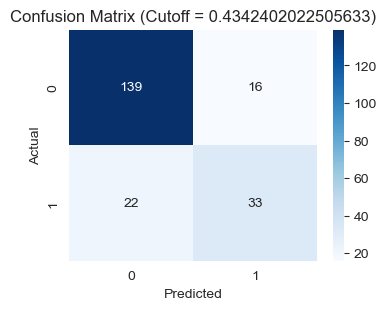

In [60]:
# Plot confusion matrix as a heatmap
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Cutoff = {cutoff})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
# Accuracy, Precision, Recall
acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best)
rec = recall_score(y_test, y_pred_best)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")

Accuracy : 0.819
Precision: 0.673
Recall   : 0.600


In [62]:
# Detailed classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       155
           1       0.67      0.60      0.63        55

    accuracy                           0.82       210
   macro avg       0.77      0.75      0.76       210
weighted avg       0.81      0.82      0.82       210



## 9. ROC Curve and Area Under ROC Curve (AUC)

The **ROC curve** plots:

- **True Positive Rate (TPR) = Recall** on the Y-axis  
- **False Positive Rate (FPR)** on the X-axis  

The **Area Under the ROC Curve (AUC)** summarizes the ROC curve in a single number:

- AUC close to **1** → very good model  
- AUC around **0.5** → model no better than random

In [63]:
# Compute FPR, TPR for various cutoff points
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
auc_value = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc_value:.3f}")

AUC: 0.823


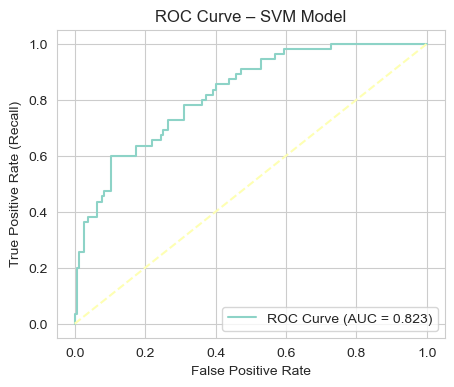

In [64]:
# Plot ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # 45-degree line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – SVM Model")
plt.legend(loc="lower right")
plt.show()

## Inference
An ROC-AUC value of 0.823 shows that the SVM model achieves good discrimination between defaulting and non-defaulting customers.
